In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Python:", sys.version)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Python: 3.13.15 (tags/v3.13.15:4061bc4, Aug  5 2026, 13:05:39) [MSC v.1944 64 bit (AMD64)]
Pandas: 3.0.6
NumPy: 2.5.3


In [2]:
current_path = Path.cwd()

print("Current working directory:")
print(current_path)

Current working directory:
f:\4\Hoc may co ban\WaterQualityProject\ai-models\colab


In [3]:
possible_paths = [
    Path("../data/water_potability.csv"),
    Path("ai-models/data/water_potability.csv"),
    Path("../ai-models/data/water_potability.csv"),
]

data_path = None

for path in possible_paths:
    if path.exists():
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError("Không tìm thấy water_potability.csv")

print("Dataset path:", data_path.resolve())

Dataset path: F:\4\Hoc may co ban\WaterQualityProject\ai-models\data\water_potability.csv


In [4]:
df = pd.read_csv(data_path)

print("Đọc dataset thành công.")
print("Kích thước dataset:", df.shape)

Đọc dataset thành công.
Kích thước dataset: (3276, 10)


In [5]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [7]:
missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    "Missing": missing_values,
    "Missing_Percent": (missing_values / len(df) * 100).round(2)
})

missing_table

,Missing,Missing_Percent
ph,491,14.99
Hardness,0,0.00
Solids,0,0.00
Chloramines,0,0.00
Sulfate,781,23.84
Conductivity,0,0.00
Organic_carbon,0,0.00
Trihalomethanes,162,4.95
Turbidity,0,0.00
Potability,0,0.00


In [8]:
duplicate_count = df.duplicated().sum()

print("Số dòng bị trùng:", duplicate_count)

Số dòng bị trùng: 0


In [9]:
target_counts = df["Potability"].value_counts().sort_index()

target_percent = (
    df["Potability"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percent": target_percent
})

target_summary

,Count,Percent
Potability,,
0,1998,60.99
1,1278,39.01


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ph,2785.0,7.080795,1.594320,0.000000,6.093092,7.036752,8.062066,14.000000
Hardness,3276.0,196.369496,32.879761,47.432000,176.850538,196.967627,216.667456,323.124000
Solids,3276.0,22014.092526,8768.570828,320.942611,15666.690297,20927.833607,27332.762127,61227.196008
Chloramines,3276.0,7.122277,1.583085,0.352000,6.127421,7.130299,8.114887,13.127000
Sulfate,2495.0,333.775777,41.416840,129.000000,307.699498,333.073546,359.950170,481.030642
Conductivity,3276.0,426.205111,80.824064,181.483754,365.734414,421.884968,481.792304,753.342620
Organic_carbon,3276.0,14.284970,3.308162,2.200000,12.065801,14.218338,16.557652,28.300000
Trihalomethanes,3114.0,66.396293,16.175008,0.738000,55.844536,66.622485,77.337473,124.000000
Turbidity,3276.0,3.966786,0.780382,1.450000,3.439711,3.955028,4.500320,6.739000
Potability,3276.0,0.390110,0.487849,0.000000,0.000000,0.000000,1.000000,1.000000


## EDA 4 - Correlation Heatmap

Mục tiêu:
- Phân tích mức độ tương quan giữa các đặc trưng số.
- Xem đặc trưng nào có quan hệ mạnh hoặc yếu với `Potability`.
- Kiểm tra khả năng tồn tại các đặc trưng có tương quan cao với nhau.

In [11]:
correlation_matrix = df.corr(numeric_only=True)

correlation_matrix

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
ph,1.000000,0.082096,-0.089288,-0.034350,0.018203,0.018614,0.043503,0.003354,-0.039057,-0.003556
Hardness,0.082096,1.000000,-0.046899,-0.030054,-0.106923,-0.023915,0.003610,-0.013013,-0.014449,-0.013837
Solids,-0.089288,-0.046899,1.000000,-0.070148,-0.171804,0.013831,0.010242,-0.009143,0.019546,0.033743
Chloramines,-0.034350,-0.030054,-0.070148,1.000000,0.027244,-0.020486,-0.012653,0.017084,0.002363,0.023779
Sulfate,0.018203,-0.106923,-0.171804,0.027244,1.000000,-0.016121,0.030831,-0.030274,-0.011187,-0.023577
Conductivity,0.018614,-0.023915,0.013831,-0.020486,-0.016121,1.000000,0.020966,0.001285,0.005798,-0.008128
Organic_carbon,0.043503,0.003610,0.010242,-0.012653,0.030831,0.020966,1.000000,-0.013274,-0.027308,-0.030001
Trihalomethanes,0.003354,-0.013013,-0.009143,0.017084,-0.030274,0.001285,-0.013274,1.000000,-0.022145,0.007130
Turbidity,-0.039057,-0.014449,0.019546,0.002363,-0.011187,0.005798,-0.027308,-0.022145,1.000000,0.001581
Potability,-0.003556,-0.013837,0.033743,0.023779,-0.023577,-0.008128,-0.030001,0.007130,0.001581,1.000000


In [12]:
target_correlation = (
    correlation_matrix["Potability"]
    .drop("Potability")
    .sort_values(key=abs, ascending=False)
)

target_correlation

Solids             0.033743
Organic_carbon    -0.030001
Chloramines        0.023779
Sulfate           -0.023577
Hardness          -0.013837
Conductivity      -0.008128
Trihalomethanes    0.007130
ph                -0.003556
Turbidity          0.001581
Name: Potability, dtype: float64

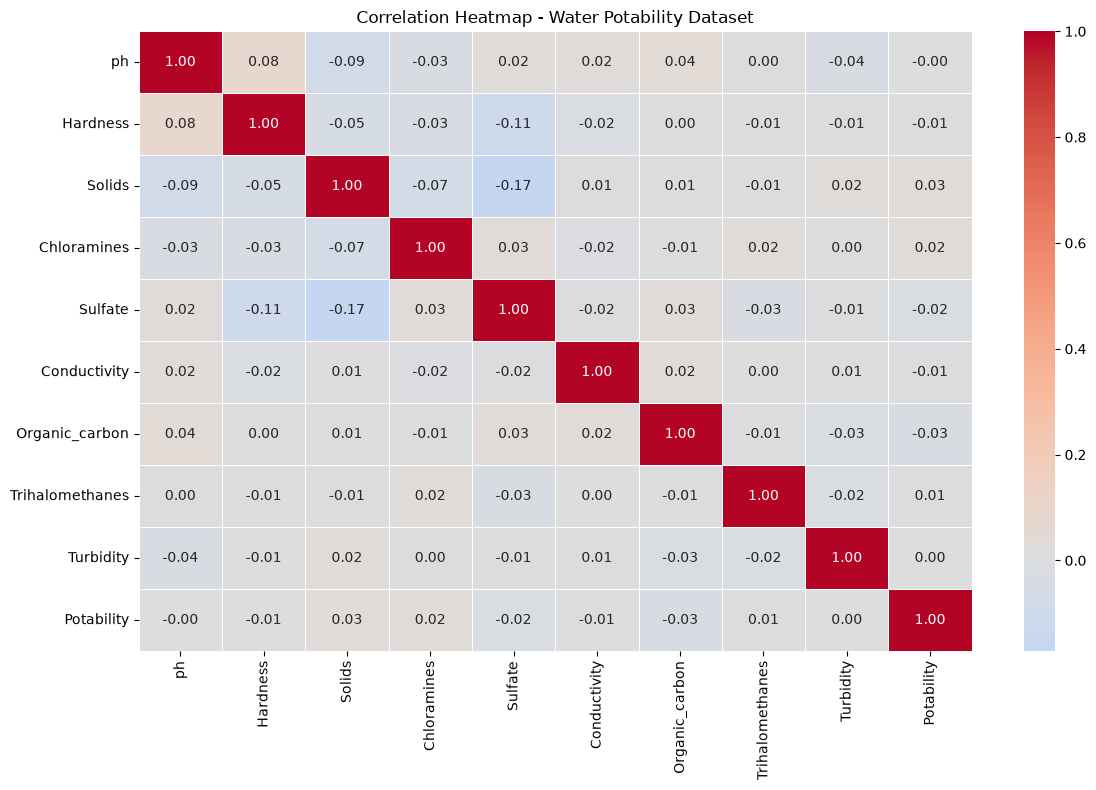

In [13]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap - Water Potability Dataset")
plt.tight_layout()
plt.show()

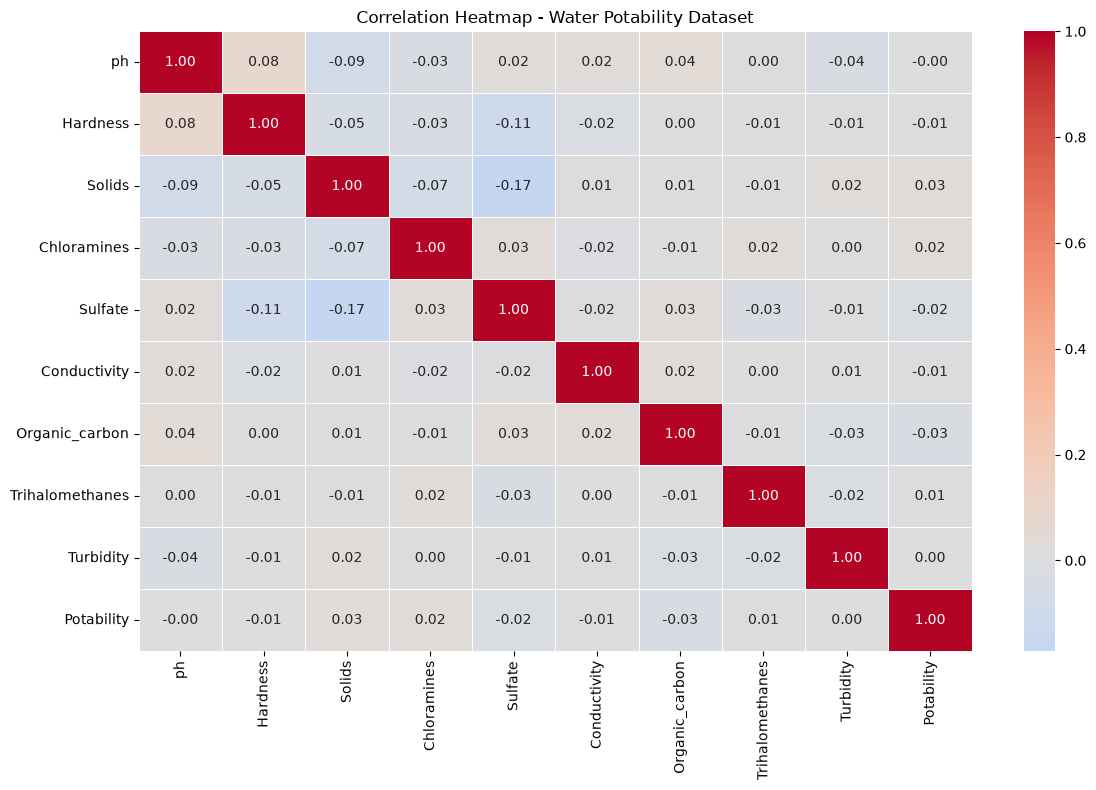

Đã lưu hình tại:
F:\4\Hoc may co ban\WaterQualityProject\docs\figures\correlation_heatmap_tv2.png


In [14]:
project_root = data_path.resolve().parents[2]

figures_dir = project_root / "docs" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

heatmap_path = figures_dir / "correlation_heatmap_tv2.png"

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap - Water Potability Dataset")
plt.tight_layout()

plt.savefig(
    heatmap_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Đã lưu hình tại:")
print(heatmap_path)

### Nhận xét Correlation Heatmap

**1. Biểu đồ cho thấy gì?**

Ma trận tương quan cho thấy phần lớn các đặc trưng trong dataset có mức tương quan tuyến tính thấp với nhau.

Đối với biến mục tiêu `Potability`, tất cả các hệ số tương quan đều có giá trị tuyệt đối rất nhỏ:

- `Solids`: 0.0337
- `Organic_carbon`: -0.0300
- `Chloramines`: 0.0238
- `Sulfate`: -0.0236
- `Hardness`: -0.0138
- `Conductivity`: -0.0081
- `Trihalomethanes`: 0.0071
- `ph`: -0.0036
- `Turbidity`: 0.0016

Trong đó, `Solids` có tương quan dương lớn nhất với `Potability`, nhưng hệ số chỉ khoảng 0.034.  
`Organic_carbon` có tương quan âm lớn nhất, khoảng -0.030.

Giữa các đặc trưng đầu vào cũng không xuất hiện cặp biến nào có tương quan tuyến tính quá cao. Một trong các cặp đáng chú ý hơn là `Solids` và `Sulfate` với hệ số tương quan khoảng -0.17, nhưng mức này vẫn tương đối thấp.

**2. Ý nghĩa đối với bài toán**

Kết quả cho thấy không có một đặc trưng đơn lẻ nào có mối quan hệ tuyến tính mạnh với khả năng uống được của nước.

Điều này cho thấy bài toán phân loại `Potability` có thể không được giải quyết tốt chỉ bằng cách xem xét từng đặc trưng riêng lẻ hoặc dựa hoàn toàn vào quan hệ tuyến tính.

Tuy nhiên, hệ số tương quan thấp không có nghĩa là các đặc trưng không có giá trị dự đoán. Các đặc trưng có thể tương tác với nhau hoặc tồn tại các quan hệ phi tuyến mà hệ số tương quan Pearson không thể hiện rõ.

**3. Quyết định xử lý tiếp theo**

- Chưa loại bỏ đặc trưng nào chỉ dựa trên Correlation Heatmap.
- Tiếp tục giữ 9 đặc trưng đầu vào để đánh giá trong quá trình huấn luyện mô hình.
- Tiếp tục phân tích sự phân bố của các đặc trưng theo từng lớp `Potability`.
- Tiếp tục kiểm tra mối quan hệ giữa các đặc trưng bằng các biểu đồ khác.
- Missing values sẽ được xử lý trong bước preprocessing bằng pipeline phù hợp để tránh data leakage.
- Các mô hình tuyến tính và phi tuyến sẽ được so sánh để đánh giá liệu quan hệ giữa các đặc trưng và `Potability` có thể được khai thác tốt hơn bởi các mô hình khác nhau hay không.

## EDA 5 - Phân bố đặc trưng theo Potability

Dựa trên Correlation Heatmap, ba đặc trưng có độ tương quan tuyệt đối với
`Potability` cao hơn các đặc trưng còn lại là:

- `Solids`
- `Organic_carbon`
- `Chloramines`

Ba đặc trưng này đồng thời không có missing values, vì vậy được sử dụng
để quan sát sự khác biệt về phân bố giữa hai lớp `Potability`.

In [16]:
selected_features = [
    "Solids",
    "Organic_carbon",
    "Chloramines"
]

group_statistics = (
    df.groupby("Potability")[selected_features]
    .agg(["mean", "median", "std"])
    .round(2)
)

group_statistics

Solids                    Organic_carbon               \
                mean    median      std           mean median   std   
Potability                                                            
0           21777.49  20809.62  8543.07          14.36  14.29  3.33   
1           22383.99  21199.39  9101.01          14.16  14.16  3.26   

           Chloramines              
                  mean median  std  
Potability                          
0                 7.09   7.09  1.5  
1                 7.17   7.22  1.7

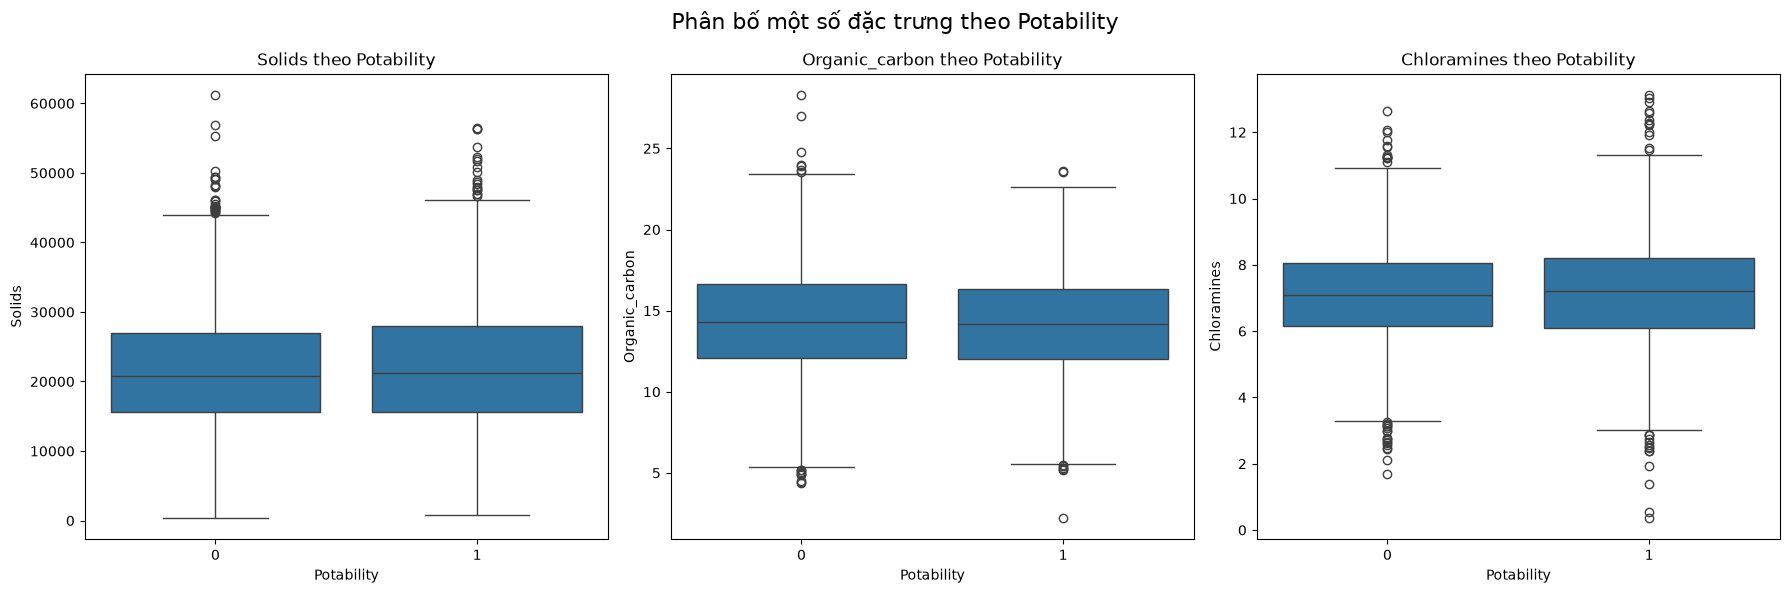

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, feature in zip(axes, selected_features):
    sns.boxplot(
        data=df,
        x="Potability",
        y=feature,
        ax=ax
    )

    ax.set_title(f"{feature} theo Potability")
    ax.set_xlabel("Potability")
    ax.set_ylabel(feature)

plt.suptitle(
    "Phân bố một số đặc trưng theo Potability",
    fontsize=16
)

plt.tight_layout()
plt.show()

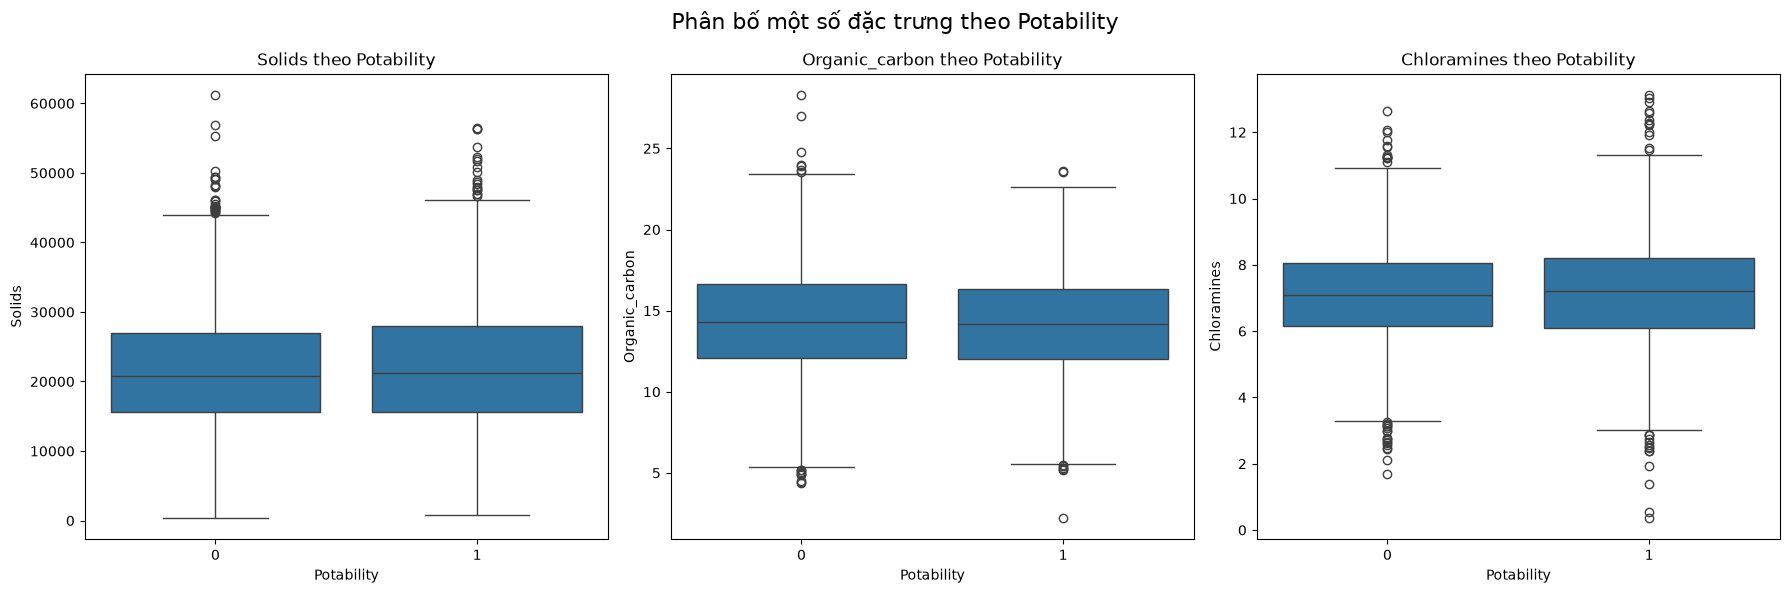

Đã lưu hình tại:
F:\4\Hoc may co ban\WaterQualityProject\docs\figures\feature_vs_potability_tv2.png


In [18]:
feature_plot_path = figures_dir / "feature_vs_potability_tv2.png"

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, feature in zip(axes, selected_features):
    sns.boxplot(
        data=df,
        x="Potability",
        y=feature,
        ax=ax
    )

    ax.set_title(f"{feature} theo Potability")
    ax.set_xlabel("Potability")
    ax.set_ylabel(feature)

plt.suptitle(
    "Phân bố một số đặc trưng theo Potability",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    feature_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Đã lưu hình tại:")
print(feature_plot_path)

### Nhận xét Feature vs Potability

**1. Biểu đồ cho thấy gì?**

Biểu đồ Boxplot so sánh phân bố của ba đặc trưng `Solids`,
`Organic_carbon` và `Chloramines` giữa hai lớp `Potability = 0`
và `Potability = 1`.

- Với `Solids`:
  - Potability = 0 có giá trị trung bình khoảng 21777.49.
  - Potability = 1 có giá trị trung bình khoảng 22383.99.
  - Trung vị lần lượt khoảng 20809.62 và 21199.39.
  - Nhóm Potability = 1 có giá trị `Solids` trung bình cao hơn một chút,
    nhưng hai phân bố chồng lấn lớn.
  - Biểu đồ cũng xuất hiện một số giá trị ngoại lệ ở phía giá trị cao.

- Với `Organic_carbon`:
  - Potability = 0 có giá trị trung bình khoảng 14.36.
  - Potability = 1 có giá trị trung bình khoảng 14.16.
  - Trung vị lần lượt khoảng 14.29 và 14.16.
  - Sự khác biệt giữa hai nhóm rất nhỏ và phần lớn phân bố chồng lấn nhau.

- Với `Chloramines`:
  - Potability = 0 có giá trị trung bình khoảng 7.09.
  - Potability = 1 có giá trị trung bình khoảng 7.17.
  - Trung vị lần lượt khoảng 7.09 và 7.22.
  - Nhóm Potability = 1 có giá trị trung bình và trung vị cao hơn nhẹ,
    nhưng chưa có sự phân tách rõ giữa hai lớp.
  - Một số giá trị ngoại lệ xuất hiện ở cả phía thấp và phía cao.

Nhìn chung, cả ba đặc trưng đều có sự chồng lấn lớn giữa hai lớp
`Potability`, phù hợp với kết quả Correlation Heatmap trước đó khi
các đặc trưng chỉ có tương quan tuyến tính rất thấp với biến mục tiêu.

**2. Ý nghĩa đối với bài toán**

Không có đặc trưng nào trong ba đặc trưng trên có thể tự mình phân tách
rõ ràng nước thuộc lớp Potability = 0 hay Potability = 1.

Điều này cho thấy việc phân loại chất lượng nước cần dựa trên sự kết hợp
của nhiều đặc trưng thay vì sử dụng một biến riêng lẻ.

Ngoài ra, sự xuất hiện của các giá trị ngoại lệ cho thấy cần xem xét
outlier trong bước preprocessing. Tuy nhiên, chưa thể kết luận các giá trị
này là dữ liệu sai vì chúng có thể là các quan sát hợp lệ của chất lượng nước.

**3. Quyết định xử lý tiếp theo**

- Không loại bỏ `Solids`, `Organic_carbon` hoặc `Chloramines` chỉ vì
  khả năng phân tách riêng lẻ thấp.
- Tiếp tục giữ các đặc trưng này để huấn luyện và so sánh các mô hình.
- Không tự động xóa các outlier ở bước EDA.
- Outlier sẽ được phân tích kỹ hơn trong giai đoạn preprocessing.
- Tiếp tục sử dụng Scatter/Pairplot để quan sát mối quan hệ giữa nhiều
  đặc trưng và khả năng hình thành các cụm theo `Potability`.

## EDA 6 - Scatter / Pairplot giữa các đặc trưng

Mục tiêu:

- Quan sát mối quan hệ giữa nhiều đặc trưng cùng lúc.
- Kiểm tra khả năng hình thành cụm giữa hai lớp `Potability`.
- Xem liệu các quan hệ phi tuyến hoặc sự kết hợp đặc trưng có giúp phân biệt
  hai lớp tốt hơn so với việc xét từng đặc trưng riêng lẻ hay không.

In [20]:
pairplot_features = [
    "Solids",
    "Organic_carbon",
    "Chloramines",
    "Hardness",
    "Potability"
]

In [21]:
pairplot_data = df[pairplot_features].copy()

pairplot_data.head()

,Solids,Organic_carbon,Chloramines,Hardness,Potability
0,20791.318981,10.379783,7.300212,204.890455,0
1,18630.057858,15.180013,6.635246,129.422921,0
2,19909.541732,16.868637,9.275884,224.236259,0
3,22018.417441,18.436524,8.059332,214.373394,0
4,17978.986339,11.558279,6.546600,181.101509,0


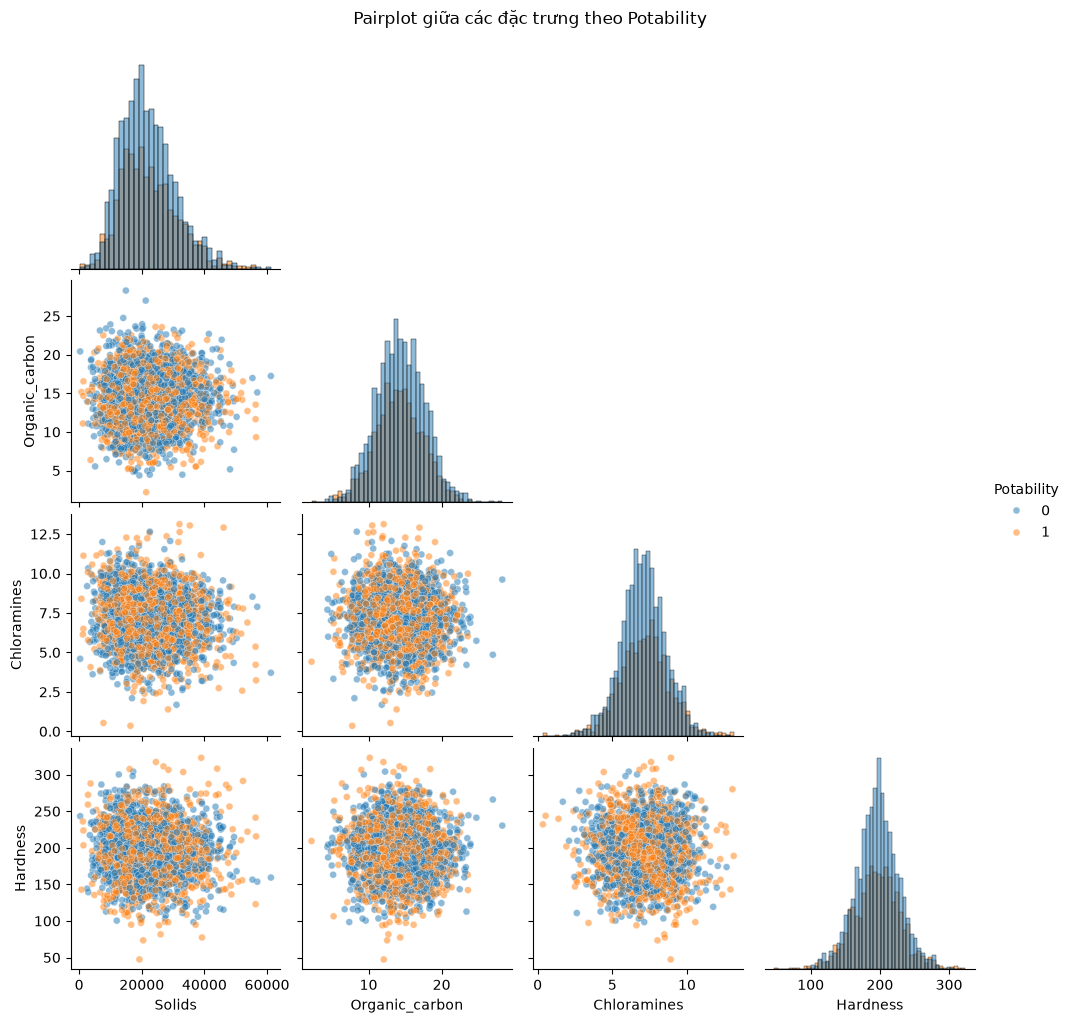

In [22]:
pair_plot = sns.pairplot(
    pairplot_data,
    hue="Potability",
    diag_kind="hist",
    corner=True,
    plot_kws={
        "alpha": 0.5,
        "s": 25
    }
)

pair_plot.fig.suptitle(
    "Pairplot giữa các đặc trưng theo Potability",
    y=1.02
)

plt.show()

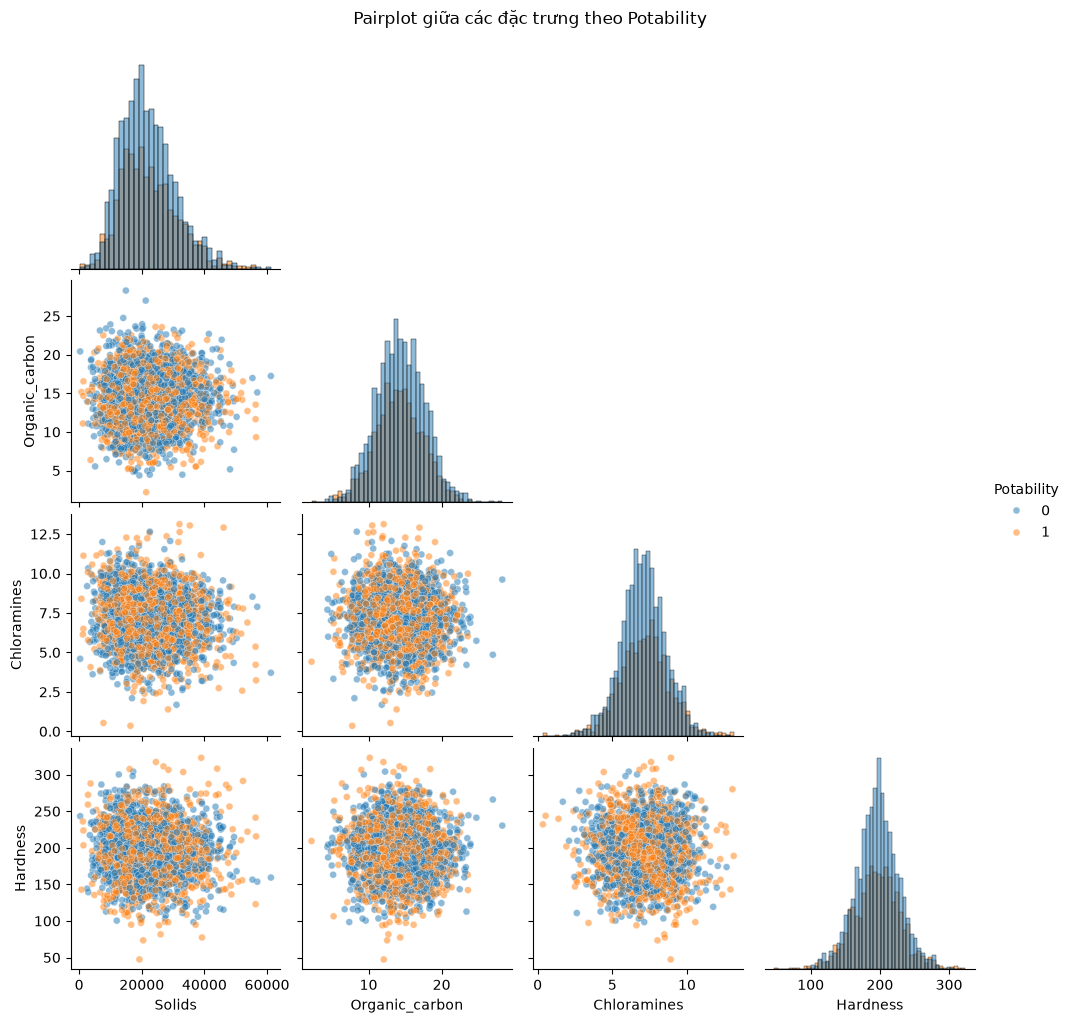

Đã lưu hình tại:
F:\4\Hoc may co ban\WaterQualityProject\docs\figures\pairplot_features_tv2.png


In [23]:
pairplot_path = figures_dir / "pairplot_features_tv2.png"

pair_plot = sns.pairplot(
    pairplot_data,
    hue="Potability",
    diag_kind="hist",
    corner=True,
    plot_kws={
        "alpha": 0.5,
        "s": 25
    }
)

pair_plot.fig.suptitle(
    "Pairplot giữa các đặc trưng theo Potability",
    y=1.02
)

pair_plot.fig.savefig(
    pairplot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Đã lưu hình tại:")
print(pairplot_path)

### Nhận xét Scatter / Pairplot

**1. Biểu đồ cho thấy gì?**

Pairplot thể hiện mối quan hệ giữa các đặc trưng:

- `Solids`
- `Organic_carbon`
- `Chloramines`
- `Hardness`

theo hai lớp `Potability = 0` và `Potability = 1`.

Các biểu đồ scatter cho thấy điểm dữ liệu của hai lớp có mức độ chồng lấn rất lớn.
Không xuất hiện vùng hoặc cụm rõ ràng có thể tách biệt hoàn toàn hai lớp.

Ví dụ:

- `Solids` và `Organic_carbon` có các điểm của hai lớp phân bố xen kẽ nhau.
- `Solids` và `Chloramines` cũng không tạo thành ranh giới phân lớp rõ ràng.
- `Organic_carbon` và `Hardness` có phân bố khá tương tự giữa hai lớp.
- `Chloramines` và `Hardness` tiếp tục cho thấy hai lớp bị trộn lẫn mạnh.

Trên đường chéo, phân bố của các đặc trưng nhìn chung tập trung quanh vùng trung tâm
và phân bố của hai lớp cũng chồng lấn đáng kể.

Số điểm của lớp `Potability = 0` xuất hiện nhiều hơn lớp `Potability = 1`,
phù hợp với phân bố target trước đó:

- Potability = 0: 1998 mẫu, khoảng 60.99%.
- Potability = 1: 1278 mẫu, khoảng 39.01%.

**2. Ý nghĩa đối với bài toán**

Việc hai lớp chồng lấn mạnh cho thấy không thể dễ dàng phân loại chất lượng nước
chỉ bằng một hoặc hai đặc trưng riêng biệt.

Kết quả này cũng phù hợp với Correlation Heatmap và Boxplot trước đó:
các đặc trưng có mức tương quan tuyến tính thấp với `Potability`
và khả năng phân tách riêng lẻ giữa hai lớp không rõ ràng.

Do đó, mô hình Machine Learning cần khai thác sự kết hợp của nhiều đặc trưng
cùng lúc.

Các mô hình có khả năng học quan hệ phi tuyến, ví dụ KNN, SVM hoặc Random Forest,
có thể được so sánh cùng với Logistic Regression để đánh giá khả năng phân loại.

**3. Quyết định xử lý tiếp theo**

- Tiếp tục giữ các đặc trưng hiện tại để huấn luyện mô hình.
- Không loại bỏ feature chỉ vì hai lớp chồng lấn trên Pairplot.
- Không tự động loại bỏ các điểm ngoại lệ quan sát được từ biểu đồ.
- Chuyển sang giai đoạn preprocessing để xử lý missing values, scaling
  và xây dựng pipeline đúng cách.
- Sử dụng cùng một tập train/test và các metric thống nhất để so sánh
  Logistic Regression, SVM, KNN và Random Forest.